In [50]:
print("hello world")

hello world


In [51]:
import sys
sys.modules.pop('feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)

In [52]:
from utils.feature_loader import load_feature_lists
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import nettoyer_lignes_vides
import pandas as pd
df_groh = pd.read_excel(r"C:\Users\romai\Desktop\travail\Copie de BAZEA.xlsx")
# taux de Nan
# for col in df_groh.columns:
#     print(round(df_groh[col].isna().mean(),2),col, )
df_groh,index_a_drop = nettoyer_lignes_vides(df_groh)
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df_groh.columns)
features_grroh = df_groh[feature_lists["Liste_features_grroh"] + feature_lists["Liste_features_scan_radio"]]
features_etiology = df_groh[feature_lists["features_etiology"]]
features_death = df_groh[feature_lists["death"]]
# print(features_grroh.columns)


In [53]:

from utils.feature_transformer import transform_features
sys.modules.pop('utils.utils_grroh',None)
from utils.utils_grroh import construire_mapping_renommage,format_to_efraim,ensure_float_clip
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df_groh.columns)

features_grroh = df_groh[feature_lists["Liste_features_grroh"] + feature_lists["Liste_features_scan_radio"]+ feature_lists["features_etiology"] ]
mapping_df = construire_mapping_renommage(feature_lists["Liste_features_grroh"] +feature_lists["Liste_features_scan_radio"] + feature_lists["features_etiology"] )
df_renomme = format_to_efraim(features_grroh, mapping_df)
df_renomme = ensure_float_clip(df_renomme)
df_nb = df_renomme.select_dtypes(include="number")
# _ = df_nb.hist(figsize=(10,8))
L_fill_mediane = ["Age"	,
                  "Time H-ICU"	,
                  "TIME SYMPTOMES-ICU",
                  "Time  DG-ICU",
                  "SOFA_score",
                  "Temp",
                  "Glasgow",
                  "Charlson_index",
                  "SaO2",
                  "PaO2/FiO2 VALUE VALUE",
                  "Resp_rate",
                  "Leukocytes",
                  "Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in L_fill_mediane
}
grroh_clean = nettoyer_nan_par_colonne(df_renomme,strategie_fill_nan)
grroh_clean["Hem_mal"]  = grroh_clean["Hem_mal"] .fillna(0)
grroh_clean_transform = transform_features(grroh_clean)
grroh_clean_transform = grroh_clean_transform.drop(columns=['Leukocytes'])

🔹 Age → NaN remplacés par la médiane (62.0)
🔹 Time H-ICU → NaN remplacés par la médiane (4.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (1.0)
🔹 Time  DG-ICU → NaN remplacés par la médiane (45.0)
🔹 SOFA_score → NaN remplacés par la médiane (6.0)
🔹 Temp → NaN remplacés par la médiane (38.0)
🔹 Glasgow → NaN remplacés par la médiane (15.0)
🔹 Charlson_index → NaN remplacés par la médiane (0.0)
🔹 SaO2 → NaN remplacés par la médiane (91.0)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (0.0)
🔹 Resp_rate → NaN remplacés par la médiane (29.0)
🔹 Leukocytes → NaN remplacés par la médiane (5.0)
🔹 Quad_no → NaN remplacés par la médiane (2.0)

✅ Nettoyage terminé. NaN restants : 2739


In [62]:
df_groh[df_groh["PAO2FIO2_meca"]>0]

,Study,PATIENT,CENTRE,SEXE,DATNAI,age,DATINC,DATADMHOSPI,DATADMREA,DSORTREA,DATSORTIEHOSP,DATEDECES,ETATSORTIEHOSP,ESORTREA,POIDSREA,TAILLE,DIABETE,COMORBRESP,ATABAC,AALCOOL,ACIRR,SIDA,Charlson,Hemopathie,nom_hemop,TYPHEMO,TUMEURSOLIDE,Type_tum_solide,metastase,greffe_organe_solide,TYPTRANSPL,DATGREFFE,Maladie_syst,type_MS,CORTICO,MDOSCORT,IMMUNSUP,Type_IS,remarques_TTT,LCHIM,...,CORTREA,TRANSF,LATA.pdt.le.sejour,DATLAT,LOS_hop,LOS_rea,delai_hop_rea,delai_diag_patho,DATDIAG,Unnamed: 164,DIAGPRINCIPAL_final.x,DIAG2,diag_texte,DIAGPRINCIPAL_final.recod,IRA-DIAG - vd,second diag,troisieme diag,Unnamed: 172,diag1,diag2,diag3,diagnostic.definitif.1.x,diagnostic.definitif.2.x,diagnostic.definitif.3.x,Pathog√®ne.1,Pathog√®ne.2,Pathog√®ne.3,diagnostic.definitif.1.bis,diagnostic.definitif.2.bis,diagnostic.definitif.3.bis,Pathog√®ne.1.bis,Pathog√®ne.2.bis,Pathog√®ne.3.bis,DIAGNOSTIC.DEF.1.x,DIAGNOSTIC.DEF.2.x,DIAGNOSTIC.DEF.3.x,PATHOGENE.DEF.1,PATHOGENE.DEF.2,PATHOGENE.DEF.3,Unnamed: 194
0,TRIALOH,01001FF,1,0.0,1954-03-03 00:00:00,55.0,2009-11-16 00:00:00,2009-10-29 00:00:00,2009-11-13 00:00:00,2009-11-19 00:00:00,2009-11-19 00:00:00,0,0.0,0,78.0,154.0,1.0,0.0,0,0.0,0.0,0.0,4.0,1,LAM,1.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,hydroxycarbamide/,1.0,...,0.0,0.0,0.0,0,6.0,6.0,15.0,17.0,2009-10-27 00:00:00,0.0,0,0,0,0,7,0,0,0,11.0,0.0,0.0,Ventre,0,0,CD,0,0,Ventre,0,0,CD,0,0,ABDOMEN,0,0,GRAMPLUS,0,0,01001FF
1,TRIALOH,01002DM,1,1.0,1959-09-10 00:00:00,50.0,2009-11-19 00:00:00,2009-10-24 00:00:00,2009-11-06 00:00:00,2009-12-02 00:00:00,2009-12-02 00:00:00,2009-12-02 00:00:00,1.0,1,74.0,169.0,0.0,0.0,0,0.0,0.0,6.0,11.0,1,Lymphome,10.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,1.0,...,1.0,1.0,1.0,2009-12-01 00:00:00,26.0,26.0,13.0,2.0,2009-11-04 00:00:00,0.0,0,0,0,0,3,0,0,0,13.0,2.0,0.0,SAM,Pneumonie,0,Enterobacter,Pseudomonas,0,SAM,Pneumonie,0,Enterobacter,Pseudomonas,0,SAM,PNEUMONIE,0,GRAMMOINS,GRAMMOINS,0,01002DM
3,TRIALOH,01004QC,1,0.0,1970-02-27 00:00:00,39.0,2009-11-20 00:00:00,2009-11-19 00:00:00,2009-11-19 00:00:00,2009-11-28 00:00:00,2009-11-28 00:00:00,2010-10-30 00:00:00,0.0,0,51.0,151.0,0.0,0.0,0,0.0,0.0,0.0,2.0,1,LAM,1.0,0,0,0,0,0,0,0,0,1.0,0,0.0,0,hydrea/,1.0,...,1.0,1.0,0.0,0,9.0,9.0,0.0,0.0,2009-11-19 00:00:00,0.0,7,0,Leucostase pulmonaire,7,2,0,0,7,7.0,0.0,0.0,AVC,Leucostase,0,0,0,0,AVC,Leucostase,0,0,0,0,AVC,LEUCOSTASE,0,0,0,0,01004QC
5,TRIALOH,01006BS,1,1.0,1936-10-09 00:00:00,73.0,2009-11-25 00:00:00,2009-10-02 00:00:00,2009-11-24 00:00:00,2009-12-06 00:00:00,2009-12-06 00:00:00,2009-12-06 00:00:00,1.0,1,44.0,0.0,0.0,1.0,1,0.0,0.0,0.0,6.0,1,Lymphome,10.0,0,0,0,0,0,0,0,0,1.0,1,0.0,0,R-CHOP/,2.0,...,0.0,0.0,1.0,2009-12-05 00:00:00,12.0,12.0,53.0,23.0,2009-11-01 00:00:00,0.0,0,0,0,0,1,0,0,0,11.0,0.0,0.0,Sepsis Origine Inconnue,0,0,Pseudomonas,0,0,Sepsis Origine Inconnue,0,0,Pseudomonas,0,0,SEPSIS ORIGINE INCONNUE,0,0,GRAMMOINS,0,0,01006BS
6,TRIALOH,01009TN,1,1.0,1957-04-24 00:00:00,52.0,2009-11-30 00:00:00,2009-09-30 00:00:00,2009-11-28 00:00:00,2009-12-16 00:00:00,2009-12-16 00:00:00,2009-12-16 00:00:00,1.0,1,74.0,185.0,0.0,1.0,1,0.0,0.0,0.0,3.0,1,Lymphome,10.0,0,0,0,0,0,0,0,0,1.0,1,0.0,0,VP16/,3.0,...,0.0,0.0,1.0,2009-12-12 00:00:00,18.0,18.0,59.0,59.0,2009-09-30 00:00:00,0.0,5,0,0,5,1,0,0,5,5.0,11.0,0.0,Pneumonie,Candid√©mie,0,Aspergillus,Enterobacter,Candida,Pneumonie,Candid√©mie,0,Aspergillus,Enterobacter,Candida,PNEUMONIE,CANDID√âMIE,0,ASPERGILLUS,GRAMMOINS,CANDIDA,01009TN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2062,high,032-0004-B-J,37,1.0,0,89.0,2017-10-20 00:00:00,2017-10-19 00:00:00,2017-10-19 00:00:00,2017-11-16 00:00:00,0,2017-11-16 00:00:00,1.0,1,73.0,174.0,0.0,0.0,0,0.0,0.0,0.0,5.0,1,Autre Hemopathie Chronique,9.0,0,0,3,0,0,0,0,0,0.0,0,0.0,0,0,1.0,...,0.

In [33]:
df_bool = df_renomme.select_dtypes(include="bool")
print(df_bool.mean())

GvHD                                0.000483
Ibr_Flu_Met                         0.003383
Sex                                 0.384485
Chemotherapy                        0.265104
Bacterial infection                 0.108990
Viral infection                     0.024166
Invasive pulmonary aspergillosis    0.005075
All fungus                          0.020300
Pneumocystis jirovecii infection    0.019333
Cardiogenic pulmonary oedema        0.032866
Disease-related infiltrates         0.023200
Drug toxicity related               0.007733
Other infection                     0.017641
Other non infectious causes         0.017883
dtype: float64


# Efraim 

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt
from utils.stats_dataset import analyser_variables_binaires
from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import analyser_nan,nettoyer_lignes_vides,nettoyer_colonnes
from utils.feature_loader import load_feature_lists, load_diagnostic_feature_map
import sys
# loads the col
FEATURE_CONFIG_PATH = "utils/feature_columns.json"
feature_lists = load_feature_lists(FEATURE_CONFIG_PATH)
Liste_features_simple = feature_lists["Liste_features_simple"]
features_radiology_dysfunction = feature_lists["features_radiology_dysfunction"]
features_etiology = feature_lists["features_etiology"]
features_death = feature_lists["death"]
# Charger le fichier Excel
df = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")

# separer colonnes explicatives et etiology
df = df[df['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')

diagnostic_feature_map = load_diagnostic_feature_map(
    FEATURE_CONFIG_PATH,
    available_columns=df.columns,
    diagnoses = ["default"] #"Bacterial infection", # A changer pour bacterial !!! 
)
all_feature_columns = []
for columns_list in diagnostic_feature_map.values():
    for feature_name in columns_list:
        if feature_name not in all_feature_columns:
            all_feature_columns.append(feature_name)
Liste_features = all_feature_columns
df_col_utils = df[Liste_features]
df_category = df[features_etiology]
df_death = df[features_death]
DIAGNOSTIC_FEATURES = diagnostic_feature_map
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","SpO2","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}
strategie_fill_nan["DG1"] = "str"
strategie_fill_nan["DG2"] = "str"
strategie_fill_nan["Sys_dis_spec"] = "str"
df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
# resultats = analyser_nan(df_col_utils, top_n=3)
# resultats_y = analyser_nan(df_category, top_n=8)
df_category = nettoyer_colonnes(df_category)
df_cat_clean,index_a_drop = nettoyer_lignes_vides(df_category)
df_features_clean = df_features_clean.drop(index=index_a_drop)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)
# format mapping_etiology[nvelle_col] = [old_col1,old_cold2 ,...]
mapping_etiology ={
                    'Bacterial infection' :['Bacterial infection'] ,
                    'Viral infection' :['Viral infection'] ,
                    'Invasive pulmonary aspergillosis' :['Invasive pulmonary aspergillosis'] ,
                    'All fungus' : ["Other fungal ",'Mucorales'],
                    'Other fungal' :["Other fungal "] ,
                    'Mucorales' : ['Mucorales'],
                    'Pneumocystis jirovecii infection' :[ 'Pneumocystis jirovecii infection'],
                    'Cardiogenic pulmonary oedema' : ['Cardiogenic pulmonary oedema'],
                    'Disease-related infiltrates':['Disease-related infiltrates'],
                    'Drug toxicity related' : ['Drug toxicity related'],
                    'Other infection' : ['Other infection '],
                    'Other non infectious causes': ['Other non infectious causes','Transfusion-related acute lung injury'],
                   # 'Undetermined cause':['Undetermined cause' ]
                    }
from utils.data_quality import fusionner_labels
df_labels_fusion = fusionner_labels(df_cat_clean, mapping_etiology, mode="max")


🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 SpO2 → NaN remplacés par la médiane (92.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)
⚠️ Colonne 'DG1' absente du DataFrame, ignorée.
⚠️ Colonne 'DG2' absente du DataFrame, ignorée.
⚠️ Colonne 'Sys_dis_spec' absente du DataFrame, ignorée.

✅ Nettoyage terminé. NaN restants : 0
Nombre de lignes totalement vides : 3055
Bacterial infection                 0.435692
Viral infection                     0.288836
Invasive pulmonary aspergillosis    0.051572
All fungus                          0.053774
Other fungal                     

# Comparasion des valeurs 

In [63]:
sys.modules.pop('utils.data_quality',None)
from utils.data_quality import compare_columns
df_with_diag = pd.concat([df_features_clean,df_labels_fusion],axis=1)

compare_columns(df_with_diag,grroh_clean_transform)

Colonnes uniquement dans df1 :
set()

Colonnes uniquement dans df2 :
set()


In [67]:
grroh_clean_transform["Hem_mal_AML"].value_counts()

Hem_mal_AML
0    4138
Name: count, dtype: int64

[Sys_dis] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 5239/6360 (82.37%) vs 3824/4138 (92.41%) -> diff -10.04 pts
    valeur=np.int64(1): 1121/6360 (17.63%) vs 314/4138 (7.59%) -> diff +10.04 pts
[Solid_tumor] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 3950/6360 (62.11%) vs 3069/4138 (74.17%) -> diff -12.06 pts
    valeur=np.int64(1): 2410/6360 (37.89%) vs 1069/4138 (25.83%) -> diff +12.06 pts
[Immuno_drugs] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 3886/6360 (61.10%) vs 3241/4138 (78.32%) -> diff -17.22 pts
    valeur=np.int64(1): 2474/6360 (38.90%) vs 897/4138 (21.68%) -> diff +17.22 pts
[Prophylaxis_viral] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 4861/6360 (76.43%) vs 3465/4138 (83.74%) -> diff -7.31 pts
    valeur=np.int64(1): 1499/6360 (23.57%) vs 673/4138 (16.26%) -> diff +7.31 pts
[Septal_line] difference d'occurrence >= 5.0 pts
    valeur=np.int64(0): 5098/6360 (80.16%) vs 3748/4138 (90.58%) -> diff -10.42 pts
  

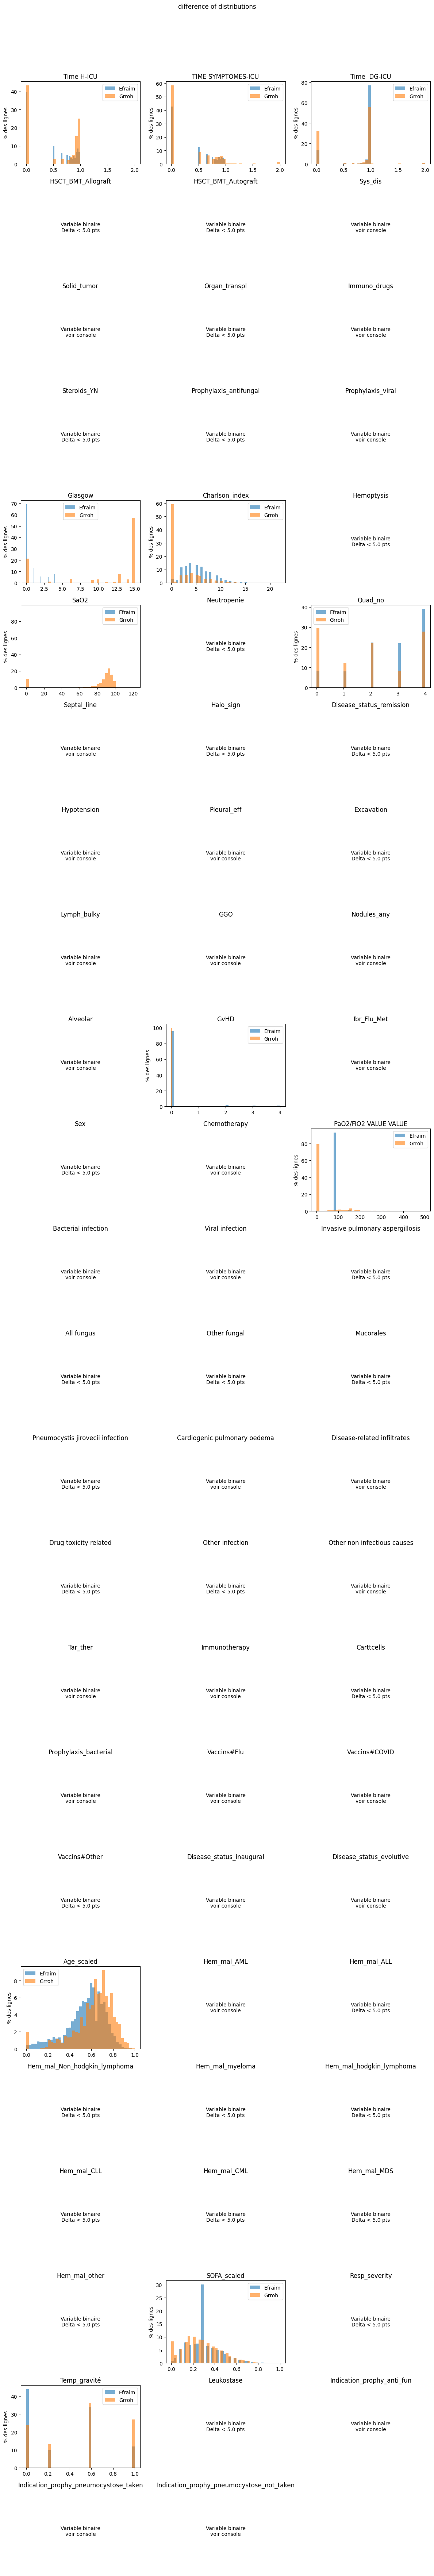

In [65]:
sys.modules.pop("utils.data_quality",None)
from utils.data_quality import plot_column_histograms

fig, axes = plot_column_histograms(
    df_left=df_with_diag,
    df_right=grroh_clean_transform,
    columns=grroh_clean_transform.columns,
    bins=40,
    label_left="Efraim",
    label_right="Grroh",
    suptitle="difference of distributions"
)
plt.show()

# Comparaison dataframes

# Graphique de nom de maladie du sang

NameError: name 'plt' is not defined

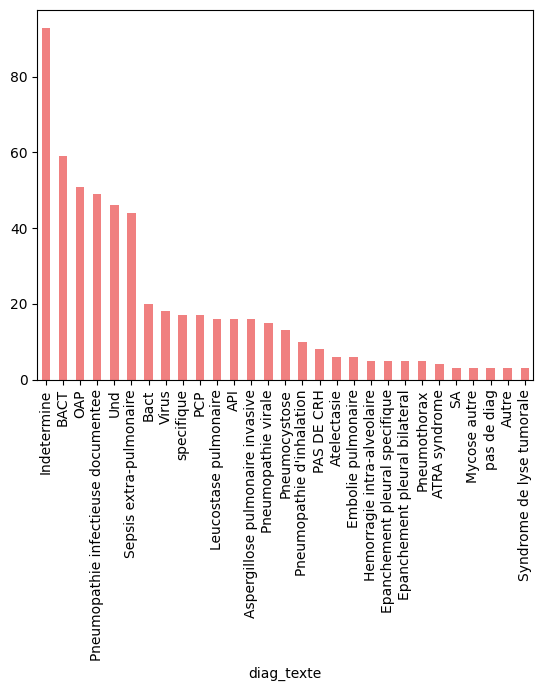

In [ ]:
df["diag_texte"].value_counts()[1:30].plot(kind='bar', color='lightcoral')
import matplotlib.pyplot as plt
plt.title("Distribution des diagnostiques")
plt.xlabel("diagnostiques")
plt.ylabel("Occurence")
plt.xticks(rotation=45, ha='right')
plt.show()